## Objective of this Notebook
The objective of this phase is to train an Ultralytics **YOLOv8** object detection model. In the final pipeline, this model will act as the "Cell Hunter." It will scan raw, uncropped microscope slides and draw bounding boxes around abnormal cells so they can be isolated and cropped for further analysis. 
To achieve this, we will:
1. Shuffle and split our preprocessed data into an 80% Training set and a 20% Validation set.
2. Generate a strict `dataset.yaml` configuration file required by the YOLO architecture.
3. Train the YOLOv8 Nano model with hyperparameter tuning (Early Stopping and Dropout) on our local GPU to prevent overfitting.

In [1]:
import os
import random
import shutil

## Dataset Architecture Preparation
YOLOv8 requires a very strict folder structure to train successfully. It demands that `images` and `labels` are separated into `train` (the textbook the AI studies) and `val` (the final exam it uses to test itself). Here, we dynamically create those sub-folders.

In [2]:
yolo_path = r"..\processed_data\yolo_dataset"

In [3]:
# 1. Create the train and val sub-folders

for folder in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    os.makedirs(os.path.join(yolo_path, folder), exist_ok=True)

In [4]:
# 2. Find all images we just generated
all_images = os.listdir(os.path.join(yolo_path, 'images'))

# Filter to only get actual images, not the folders we just created
all_images = [f for f in all_images if f.endswith('.bmp')]

# Shuffle them randomly so the model gets a good mix of all classes
random.shuffle(all_images)

## Data Shuffling and Train/Validation Split
To ensure our model generalizes well to unseen data, we gather all the `.bmp` images we generated in Phase 1 and shuffle them completely randomly. We then mathematically split the dataset:
* **80% Training:** Used to teach the AI.
* **20% Validation:** Locked away and only used to grade the AI's accuracy.

In [5]:
# Calculate 80% for training, 20% for validation
split_index = int(len(all_images) * 0.8)

train_images = all_images[:split_index]
val_images = all_images[split_index:]

In [6]:
def move_files(image_list, split_name):
    for img_name in image_list:
        # Move image
        src_img = os.path.join(yolo_path, 'images', img_name)
        dst_img = os.path.join(yolo_path, 'images', split_name, img_name)
        if os.path.exists(src_img):
            shutil.move(src_img, dst_img)
        
        # Move corresponding label
        label_name = img_name.replace('.bmp', '.txt')
        src_label = os.path.join(yolo_path, 'labels', label_name)
        dst_label = os.path.join(yolo_path, 'labels', split_name, label_name)
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)
            
move_files(train_images, 'train')
move_files(val_images, 'val')


## Generating the Configuration File (dataset.yaml)

YOLO models cannot read data without a map. We generate a `.yaml` configuration file that acts as a blueprint, telling the YOLO architecture exactly where the root directory is, where to find the train/val images, and explicitly defining our 5 cervical cell classes.

In [ ]:
yaml_content = f"""path: {yolo_path}
train: images/train
val: images/val
names:
  0: Dyskeratotic
  1: Koilocytotic
  2: Metaplastic
  3: Parabasal
  4: Superficial-Intermediate
"""
with open(os.path.join(yolo_path, 'dataset.yaml'), 'w') as f:
    f.write(yaml_content)

In [8]:
from ultralytics import YOLO

## YOLOv8 Model Training & Hyperparameter Tuning
This is where the Deep Learning happens. We initialize the `yolov8n.pt` (Nano) weights and begin training. 

**Hyperparameter Optimization:**
To prevent the model from overfitting on our dataset, we implemented the following manual hyperparameters:
* `epochs=100`: Extended training duration for complex feature extraction.
* `patience=15`: An **Early Stopping** mechanism that halts training if the validation loss fails to improve for 15 consecutive epochs.
* `dropout=0.1`: A regularization technique that randomly drops 10% of neuron connections to force generalized learning rather than memorization.
* `device=0`: Bypasses the CPU to run tensor calculations exclusively on the local NVIDIA RTX 4050 GPU.


In [ ]:
# model = YOLO('yolov8n.pt') 
# epochs = 100

# # Train the model using your GPU
# results = model.train(
#     data=r"..\processed_data\yolo_dataset\dataset.yaml", 
#     epochs=epochs,        
#     imgsz=640,        # Resizes images so they don't crash your GPU memory
#     batch=8,          # Processes 8 images at a time
#     device=0,         # '0' explicitly tells PyTorch to use your NVIDIA RTX 4050
#     name='sipakmed_yolo', # Folder name where the results will be saved
#     plots=True,        # Automatically generates beautiful loss graphs!
#     patience=15,          # ANTI-OVERFITTING: Stop early if no improvement after 15 epochs
#     dropout=0.1           # ANTI-OVERFITTING: Randomly drop 10% of neurons to prevent memorization
# )


Ultralytics 8.4.115  Python-3.10.9 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\processed_data\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builde

AMP: checks passed 
train: Fast image access  (ping: 0.20.1 ms, read: 1561.8163.3 MB/s, size: 9216.1 KB)
train: Scanning E:\SIPaKMeD\processed_data\yolo_dataset\labels\train.cache... 927 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 927/927  0.0s
val: Fast image access  (ping: 0.70.6 ms, read: 844.5166.9 MB/s, size: 9216.1 KB)
val: Scanning E:\SIPaKMeD\processed_data\yolo_dataset\labels\val.cache... 349 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to D:\CodeNebula\VS Code\Python\Artificial intelligence\runs\detect\sipakmed_yolo-2\labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to D:\CodeNebula\VS Code\Python\Artificial intellig

e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builde


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      1.08G      1.436      3.476      1.263         31        640: 100% ━━━━━━━━━━━━ 116/116 8.0it/s 14.4s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 7.1it/s 3.1s0.1s
                   all        349       1474      0.367       0.18       0.23      0.154

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      1.18G      1.335      2.632      1.213         52        640: 0% ──────────── 0/116  0.1s

...

     98/100      1.19G       0.73     0.5863        0.9         20        640: 100% ━━━━━━━━━━━━ 116/116 13.4it/s 8.7s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 10.7it/s 2.1s.1ss
                   all        349       1474      0.873      0.896      0.946      0.791

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/100      1.19G     0.6968     0.4998     0.9044         30        640: 0% ──────────── 1/116 2.0it/s 0.1s<57.0s

e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builde

     99/100      1.19G     0.7396     0.5903     0.9041         34        640: 100% ━━━━━━━━━━━━ 116/116 13.4it/s 8.7s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 10.7it/s 2.1s.1ss
                   all        349       1474      0.885      0.888      0.947      0.792

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/100      1.19G     0.6782      0.544      0.885         21        640: 0% ──────────── 1/116 1.9it/s 0.2s<59.3s

e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
e:\SIPaKMeD\sipakmed_env\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builde

    100/100      1.19G     0.7247     0.5604     0.8924         29        640: 100% ━━━━━━━━━━━━ 116/116 13.4it/s 8.7s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 10.8it/s 2.0s.1ss
                   all        349       1474      0.881      0.894      0.946      0.792

100 epochs completed in 0.341 hours.
Optimizer stripped from D:\CodeNebula\VS Code\Python\Artificial intelligence\runs\detect\sipakmed_yolo-2\weights\last.pt, 6.2MB
Optimizer stripped from D:\CodeNebula\VS Code\Python\Artificial intelligence\runs\detect\sipakmed_yolo-2\weights\best.pt, 6.2MB

Validating D:\CodeNebula\VS Code\Python\Artificial intelligence\runs\detect\sipakmed_yolo-2\weights\best.pt...
Ultralytics 8.4.115  Python-3.10.9 torch-2.5.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P         

## Evaluation & Visualizing the Metrics
Once training is complete (or stopped early by our `patience` hyperparameter), YOLO automatically evaluates its own performance. Below, we extract the results from the hidden `.csv` files to visualize the model's learning curve, confirming that the loss decreased and the mAP@50 accuracy increased as training progressed. We also print the visual bounding box predictions from the validation set!


In [12]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

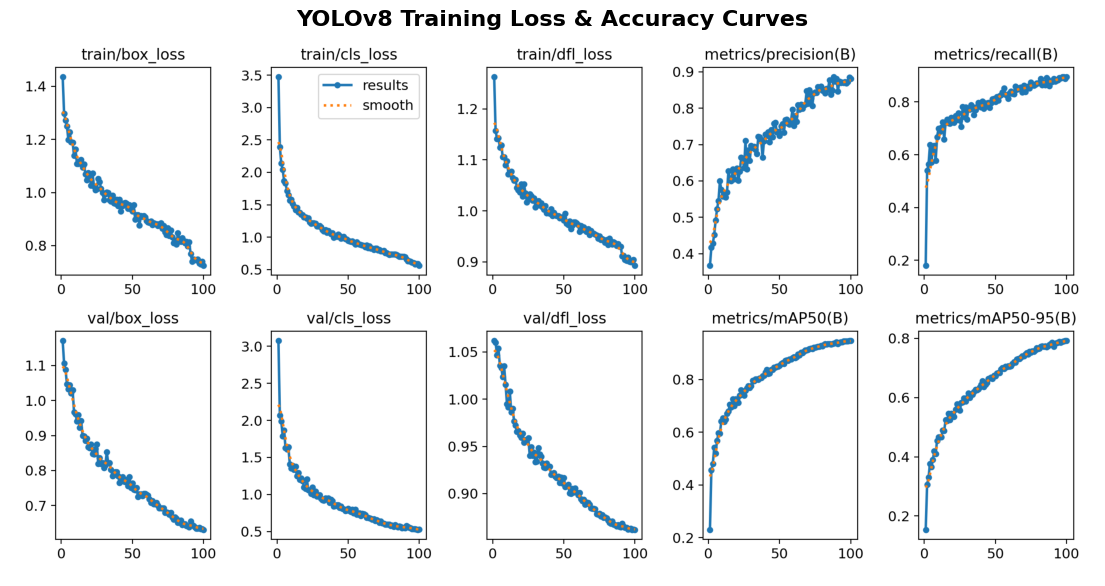

In [ ]:
# Create a large blank canvas
plt.figure(figsize=(14, 10))
# Load and display the Loss Graph
results_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\results.png")

plt.imshow(results_img)
# Hide the axis numbers and add a title
plt.axis('off')
plt.title("YOLOv8 Training Loss & Accuracy Curves", fontsize=16, fontweight='bold')
plt.show()

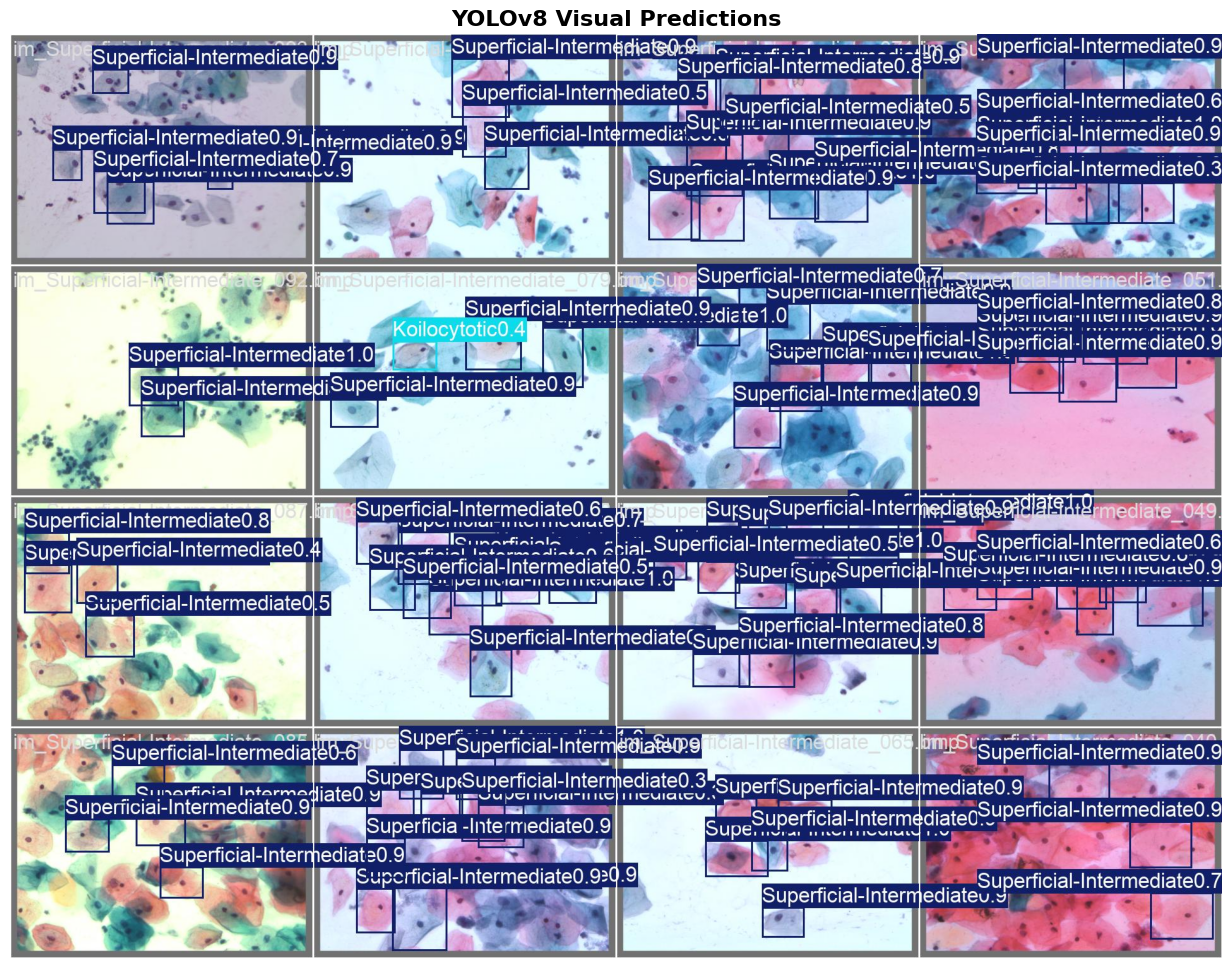

In [ ]:
# Create an even larger canvas for the cell images
plt.figure(figsize=(16, 12))
# Load and display the AI Predictions
pred_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\val_batch0_pred.jpg")

plt.imshow(pred_img)

plt.axis('off')
plt.title("YOLOv8 Visual Predictions", fontsize=16, fontweight='bold')
plt.show()

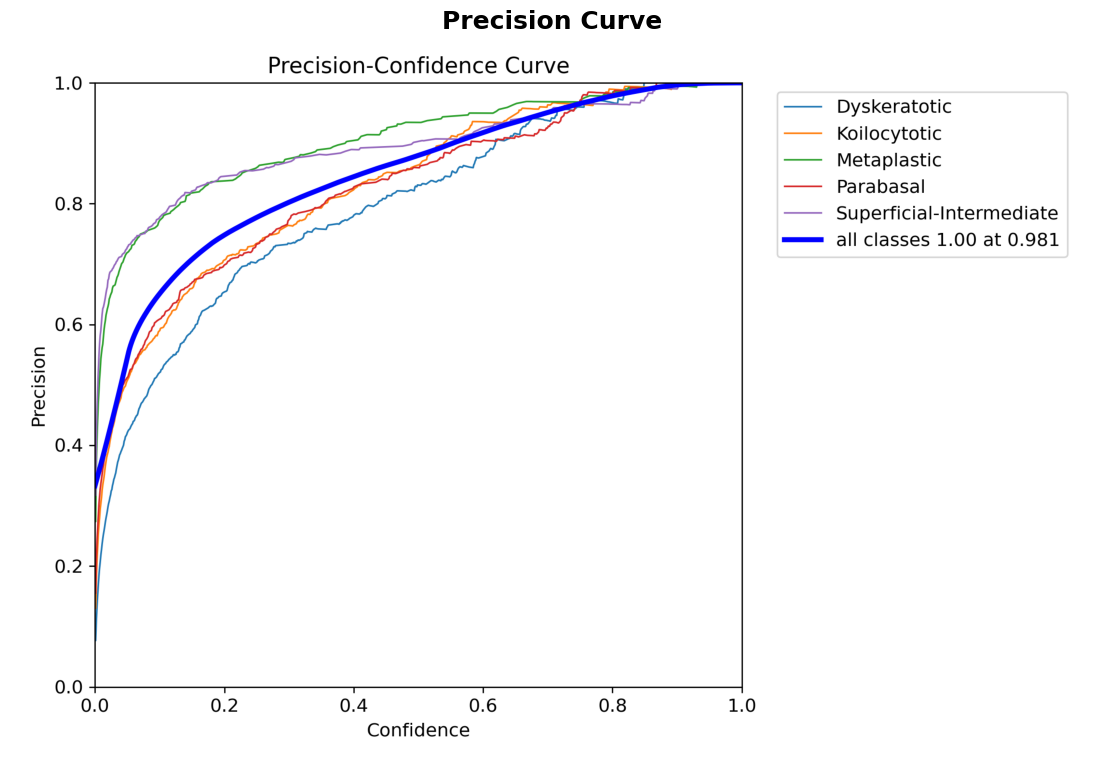

In [ ]:
plt.figure(figsize=(14, 10))
p_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\BoxP_curve.png")

plt.imshow(p_img)

plt.axis('off')
plt.title("Precision Curve", fontsize=18, fontweight='bold')
plt.show()

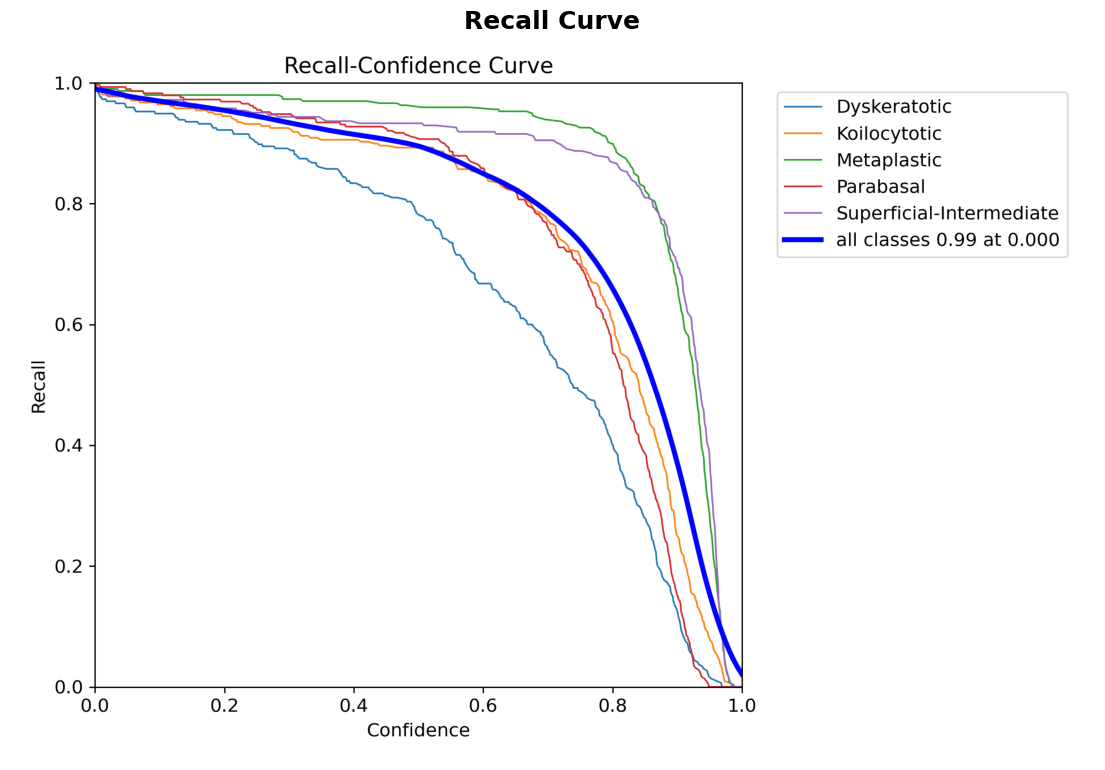

In [ ]:
plt.figure(figsize=(14, 10))
r_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\BoxR_curve.png")

plt.imshow(r_img)

plt.axis('off')
plt.title("Recall Curve", fontsize=18, fontweight='bold')
plt.show()

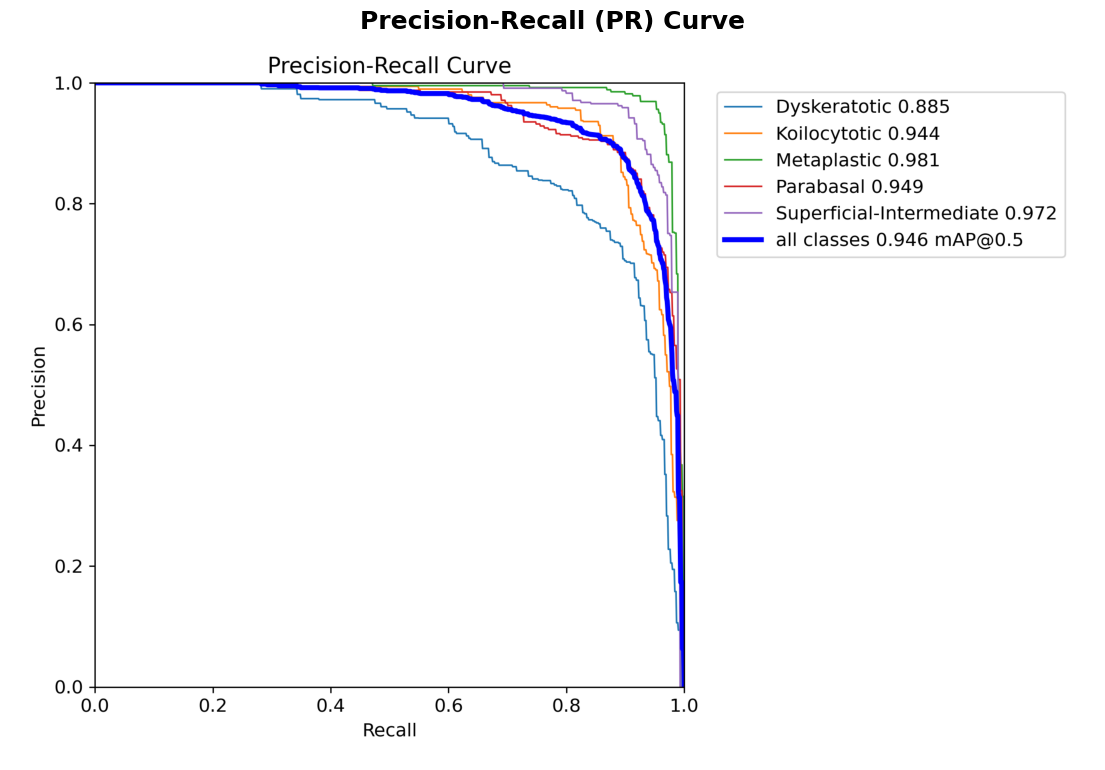

In [ ]:
plt.figure(figsize=(14, 10))
pr_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\BoxPR_curve.png")

plt.imshow(pr_img)

plt.axis('off')
plt.title("Precision-Recall (PR) Curve", fontsize=18, fontweight='bold')
plt.show()

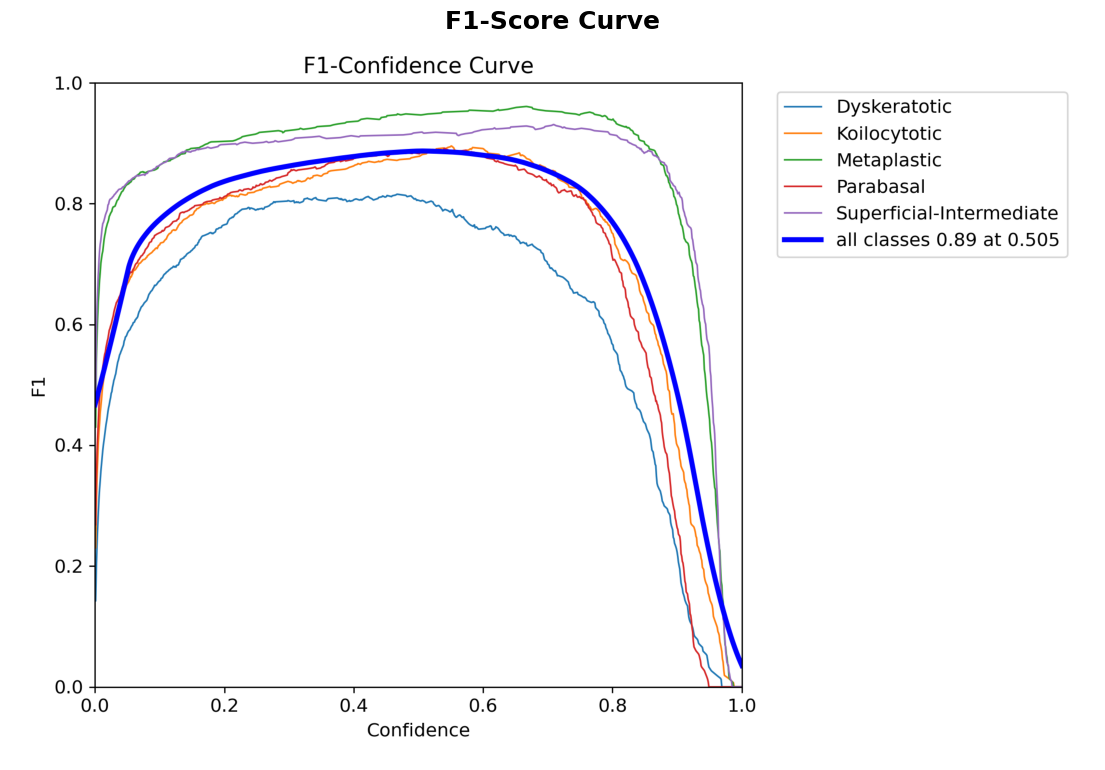

In [ ]:
plt.figure(figsize=(14, 10))
f1_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\BoxF1_curve.png")

plt.imshow(f1_img)

plt.axis('off')
plt.title("F1-Score Curve", fontsize=18, fontweight='bold')
plt.show()

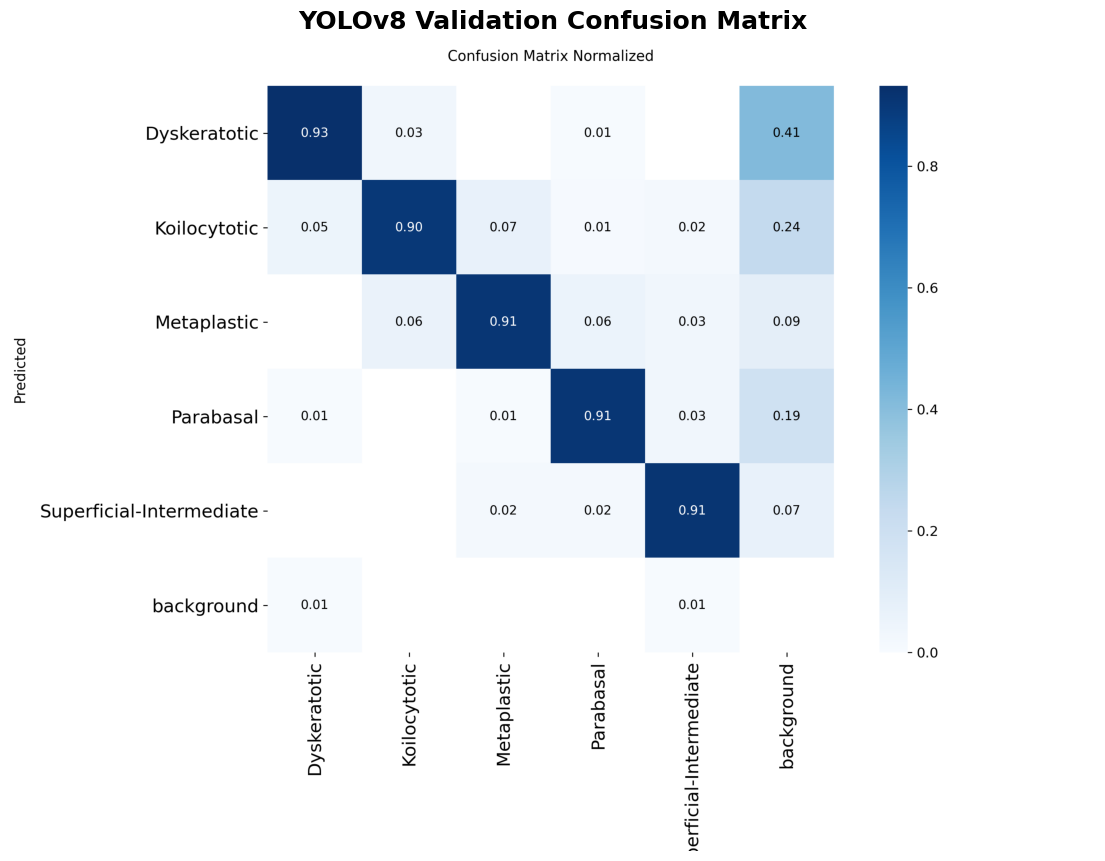

In [ ]:
# Create the canvas
plt.figure(figsize=(14, 12))

# Load and display the Normalized Confusion Matrix
# (Normalized is better for papers because it shows percentages between 0.0 and 1.0)
conf_img = mpimg.imread(r"..\runs\detect\sipakmed_yolo\confusion_matrix_normalized.png")
plt.imshow(conf_img)

# Hide the axis numbers and add a title
plt.axis('off')
plt.title("YOLOv8 Validation Confusion Matrix", fontsize=18, fontweight='bold')
plt.show()

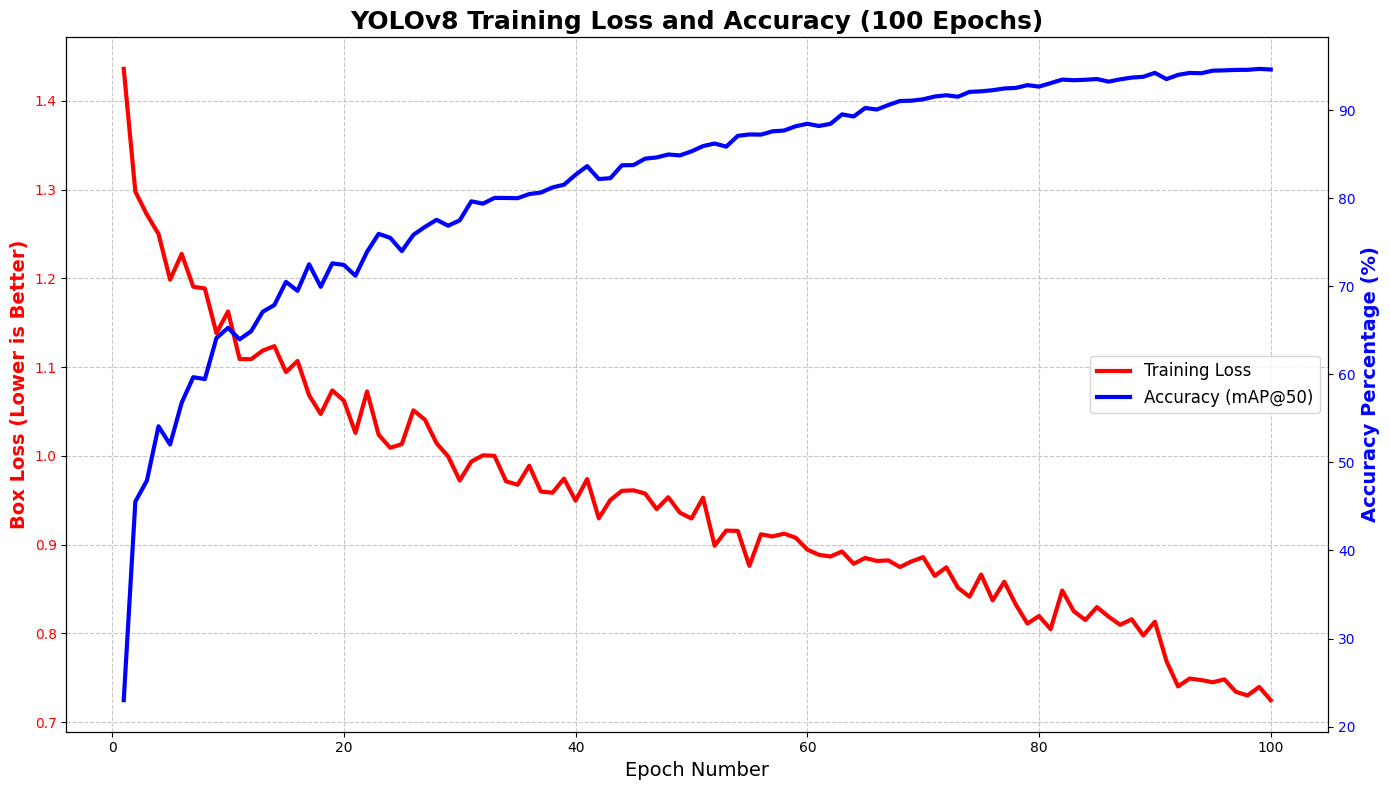

In [ ]:
# 1. Load the raw training data
df = pd.read_csv(r"..\runs\detect\sipakmed_yolo\results.csv")
df.columns = df.columns.str.strip()
epochs = df['epoch']
accuracy = df['metrics/mAP50(B)'] * 100
loss = df['train/box_loss']

# 2. Setup the single canvas
fig, ax1 = plt.subplots(figsize=(14, 8))

# 3. Plot Loss on the primary (Left) Y-axis in RED (Removed markers for a smooth line)
ax1.plot(epochs, loss, color='red', linewidth=3, label='Training Loss')
ax1.set_xlabel('Epoch Number', fontsize=14)
ax1.set_ylabel('Box Loss (Lower is Better)', color='red', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, linestyle='--', alpha=0.7)

# 4. Create a secondary (Right) Y-axis for Accuracy in BLUE
ax2 = ax1.twinx() 
ax2.plot(epochs, accuracy, color='blue', linewidth=3, label='Accuracy (mAP@50)')
ax2.set_ylabel('Accuracy Percentage (%)', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# 5. Add a unified title and Legend
plt.title('YOLOv8 Training Loss and Accuracy (100 Epochs)', fontsize=18, fontweight='bold')
# Combine the legends so they both show up in one box
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
final_epoch = df.tail(1)

final_loss = final_epoch['train/box_loss'].values[0]
final_accuracy = final_epoch['metrics/mAP50(B)'].values[0] * 100

print("-" * 45)
print("YOLOv8 FINAL 100-EPOCH RESULTS ")
print("-" * 45)
print(f"Final Training Loss        : {final_loss:.4f}")
print(f"Final Accuracy (mAP@50)    : {final_accuracy:.2f}%")
print("-" * 45)

---------------------------------------------
YOLOv8 FINAL 100-EPOCH RESULTS 
---------------------------------------------
Final Training Loss        : 0.7247
Final Accuracy (mAP@50)    : 94.61%
---------------------------------------------
